In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# DATASET1 (Healthcare attrition)

In [21]:
df=pd.read_csv("EmployeeArt/dataset2_indian.csv")
# df=df.drop(columns=["EmployeeID"])
# df["Emp_ID"].value_counts()

In [22]:
df.columns

Index(['EmployeeID', 'FullName', 'Age', 'Gender', 'Department', 'Designation',
       'EducationQualification', 'MonthlySalary', 'DateOfJoining',
       'YearsWithCompany', 'YearsInRole', 'AppraisalRating', 'TrainingHours',
       'DoesOvertime', 'JobSatisfaction', 'WorkLifeBalance', 'MaritalStatus',
       'PreviousCompanies', 'DistanceFromHome', 'LeavesTaken', 'City',
       'LeftCompany'],
      dtype='object')

In [23]:
df=df.drop(columns=["EmployeeID","FullName","DateOfJoining"])


In [28]:
df["City"].value_counts()

City
Mumbai       745
Hyderabad    737
Delhi        732
Chennai      719
Kolkata      707
Bengaluru    681
Pune         679
Name: count, dtype: int64

In [ ]:
df.dtypes

Age                         int64
Gender                     object
Department                 object
Designation                object
EducationQualification     object
MonthlySalary               int64
DateOfJoining              object
YearsWithCompany            int64
YearsInRole                 int64
AppraisalRating             int64
TrainingHours               int64
DoesOvertime               object
JobSatisfaction             int64
WorkLifeBalance             int64
MaritalStatus              object
PreviousCompanies           int64
DistanceFromHome          float64
LeavesTaken                 int64
City                       object
LeftCompany                object
dtype: object

## EDA


In [30]:
df.dtypes

Age                         int64
Gender                     object
Department                 object
Designation                object
EducationQualification     object
MonthlySalary               int64
YearsWithCompany            int64
YearsInRole                 int64
AppraisalRating             int64
TrainingHours               int64
DoesOvertime               object
JobSatisfaction             int64
WorkLifeBalance             int64
MaritalStatus              object
PreviousCompanies           int64
DistanceFromHome          float64
LeavesTaken                 int64
City                       object
LeftCompany                object
dtype: object

In [29]:
df.columns.shape

(19,)

In [31]:
col = df["LeftCompany"]
df = df.drop("LeftCompany", axis=1)
df["LeftCompany"] = col

In [ ]:
# df.columns

In [32]:

CategoricalCols=np.zeros(len(df.columns))
NumericCols=np.zeros(len(df.columns))

CategoricalColsIndex=[] # index from 0
NumericColsIndex=[]
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes)):
    if dtype=="object":
        CategoricalCols[i]=1
        CategoricalColsIndex.append(i)
        df[col] = df[col].astype('category')
    else:
        NumericCols[i]=1
        NumericColsIndex.append(i)


In [33]:
df.columns

Index(['Age', 'Gender', 'Department', 'Designation', 'EducationQualification',
       'MonthlySalary', 'YearsWithCompany', 'YearsInRole', 'AppraisalRating',
       'TrainingHours', 'DoesOvertime', 'JobSatisfaction', 'WorkLifeBalance',
       'MaritalStatus', 'PreviousCompanies', 'DistanceFromHome', 'LeavesTaken',
       'City', 'LeftCompany'],
      dtype='object')

In [35]:
df.shape

(5000, 19)

In [ ]:
# NumericCols
# print(NumericColsIndex)

In [39]:
df.LeftCompany

0       0
1       0
2       1
3       0
4       1
       ..
4995    0
4996    0
4997    0
4998    1
4999    0
Name: LeftCompany, Length: 5000, dtype: category
Categories (2, int64): [0, 1]

In [37]:
df["LeftCompany"] = df["LeftCompany"].map({"No": 0, "Yes": 1})


In [40]:
# df.columns
corrmatrix=df.corr(numeric_only=True)
corrmatrix.head(23)

,Age,MonthlySalary,YearsWithCompany,YearsInRole,AppraisalRating,TrainingHours,JobSatisfaction,WorkLifeBalance,PreviousCompanies,DistanceFromHome,LeavesTaken
Age,1.000000,-0.008263,0.015336,0.029514,-0.017205,0.002652,0.008514,-0.006183,-0.003127,-0.014488,0.005425
MonthlySalary,-0.008263,1.000000,0.033514,0.000336,0.019864,-0.009840,0.003053,0.008333,0.009731,-0.010728,-0.019062
YearsWithCompany,0.015336,0.033514,1.000000,0.548119,-0.009266,0.002722,0.018996,-0.009084,-0.021314,-0.009286,0.012921
YearsInRole,0.029514,0.000336,0.548119,1.000000,0.002009,-0.008320,-0.004028,-0.011346,-0.015962,0.010247,0.004829
AppraisalRating,-0.017205,0.019864,-0.009266,0.002009,1.000000,0.012981,-0.002791,0.005182,-0.024485,0.006226,-0.011461
TrainingHours,0.002652,-0.009840,0.002722,-0.008320,0.012981,1.000000,0.010413,-0.005096,0.011283,0.016954,-0.033514
JobSatisfaction,0.008514,0.003053,0.018996,-0.004028,-0.002791,0.010413,1.000000,0.020973,-0.007408,-0.012937,-0.013981
WorkLifeBalance,-0.006183,0.008333,-0.009084,-0.011346,0.005182,-0.005096,0.020973,1.000000,0.033855,-0.036540,-0.005432
PreviousCompanies,-0.003127,0.009731,-0.021314,-0.015962,-0.024485,0.011283,-0.007408,0.033855,1.000000,-0.008320,-0.000868
DistanceFromHome,-0.014488,-0.010728,-0.009286,0.010247,0.006226,0.016954,-0.012937,-0.036540,-0.008320,1.000000,-0.022378


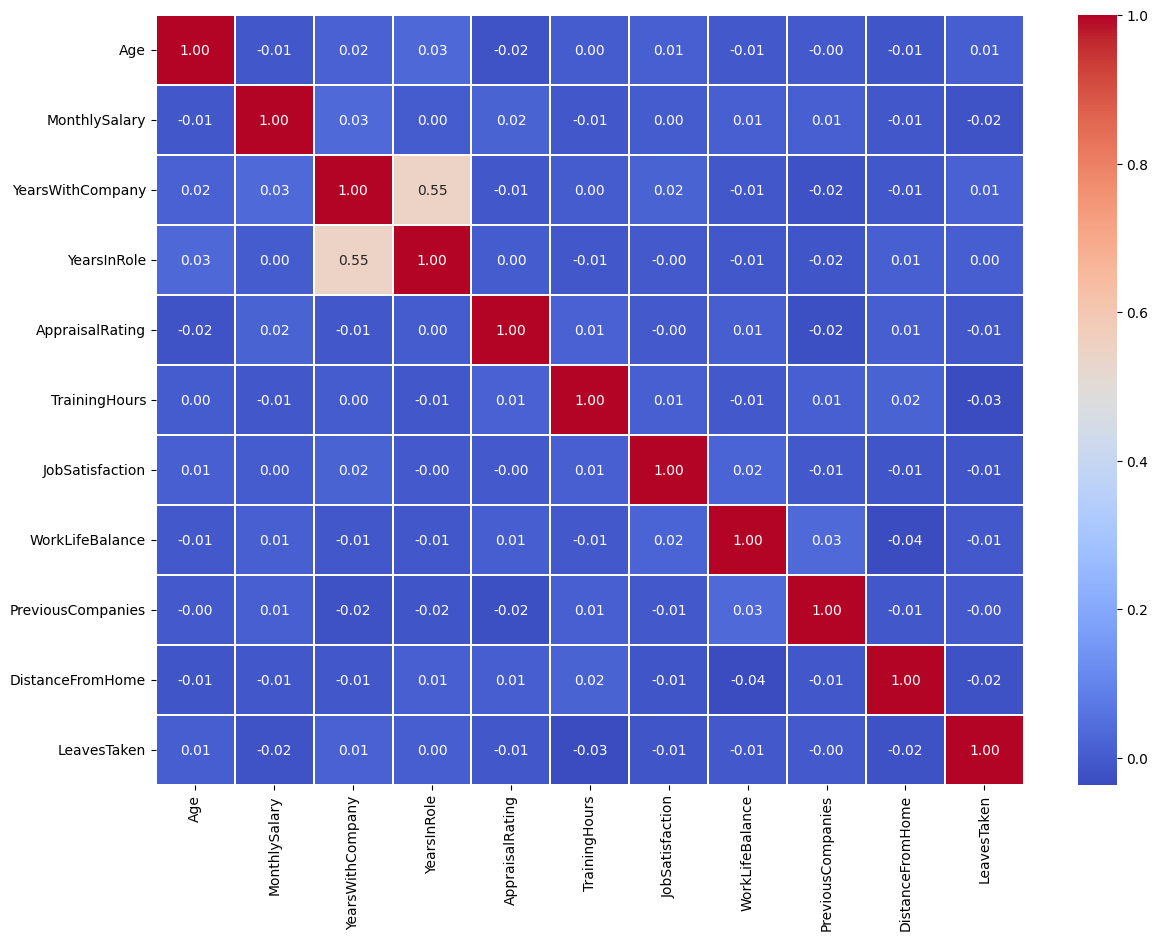

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))  
sns.heatmap(corrmatrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.1)
plt.show()


In [ ]:
# high corellation between performance rating and salary hike
# job level nad years of working

In [42]:
categorical_df = df.select_dtypes(include=['category'])
categorical_df

,Gender,Department,Designation,EducationQualification,DoesOvertime,MaritalStatus,City,LeftCompany
0,Other,HR,Accounts Officer,B.Tech,Yes,Single,Mumbai,0
1,Female,IT,Accounts Officer,B.Tech,No,Divorced,Kolkata,0
2,Male,IT,Software Engineer,Diploma,No,Married,Bengaluru,1
3,Other,HR,Accounts Officer,Diploma,Yes,Married,Kolkata,0
4,Other,Admin,Sales Associate,B.Tech,No,Single,Delhi,1
...,...,...,...,...,...,...,...,...
4995,Female,Accounts,HR Executive,MBA,No,Single,Hyderabad,0
4996,Other,Accounts,Office Assistant,M.Com,No,Divorced,Delhi,0
4997,Female,Accounts,Office Assistant,MBA,No,Divorced,Kolkata,0
4998,Other,Sales,Office Assistant,M.Com,No,Single,Pune,1


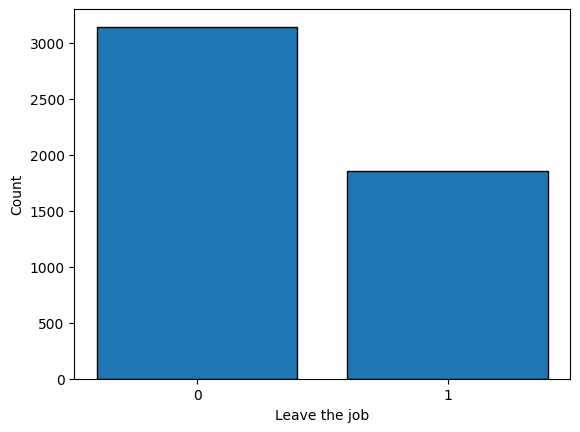

In [43]:
counts = df["LeftCompany"].value_counts().sort_index()

plt.bar(counts.index, counts.values, edgecolor='black')
plt.xticks(counts.index) # imp
plt.xlabel("Leave the job")
plt.ylabel("Count")
plt.show()

In [44]:
non_categorical_cols = df.select_dtypes(include=['number']).columns

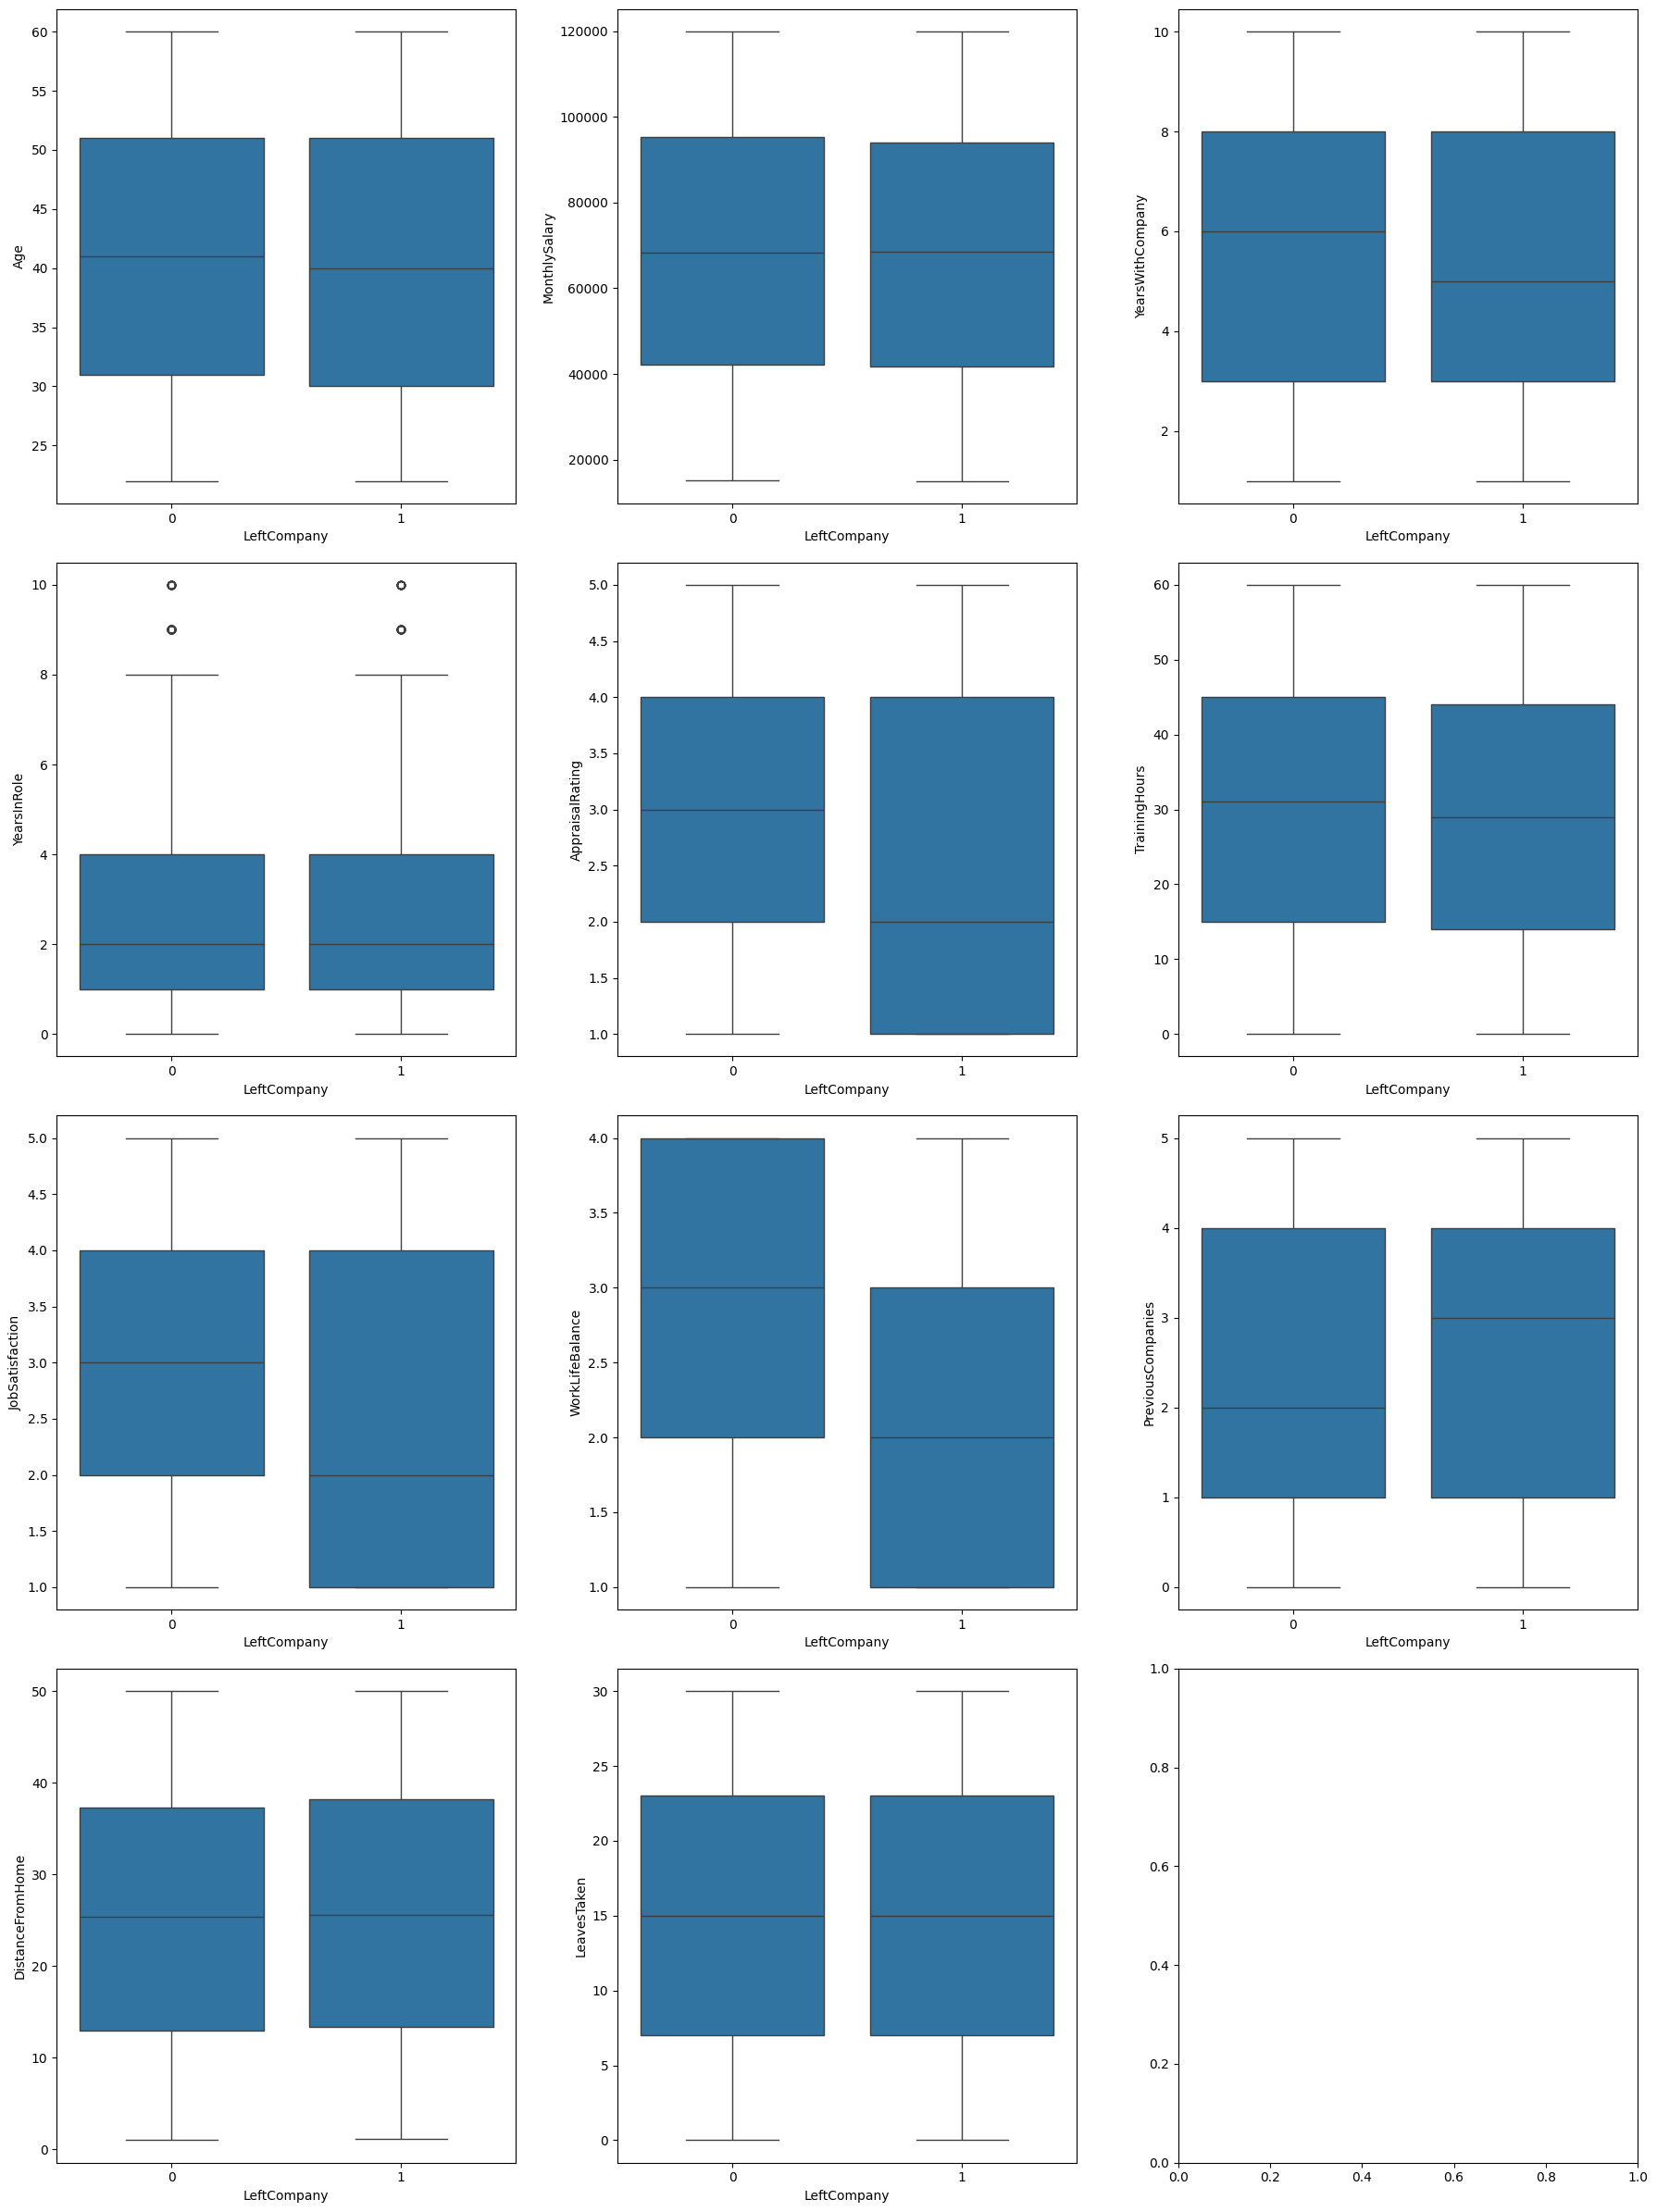

In [46]:
import math

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0
for i in df.columns:
    if df[i].dtype!="category":
        sns.boxplot(ax=axes[row,col],x=df['LeftCompany'],y=df[i])
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()

In [47]:
df.dtypes

Age                          int64
Gender                    category
Department                category
Designation               category
EducationQualification    category
MonthlySalary                int64
YearsWithCompany             int64
YearsInRole                  int64
AppraisalRating              int64
TrainingHours                int64
DoesOvertime              category
JobSatisfaction              int64
WorkLifeBalance              int64
MaritalStatus             category
PreviousCompanies            int64
DistanceFromHome           float64
LeavesTaken                  int64
City                      category
LeftCompany               category
dtype: object

In [ ]:
# df[""].value_counts()

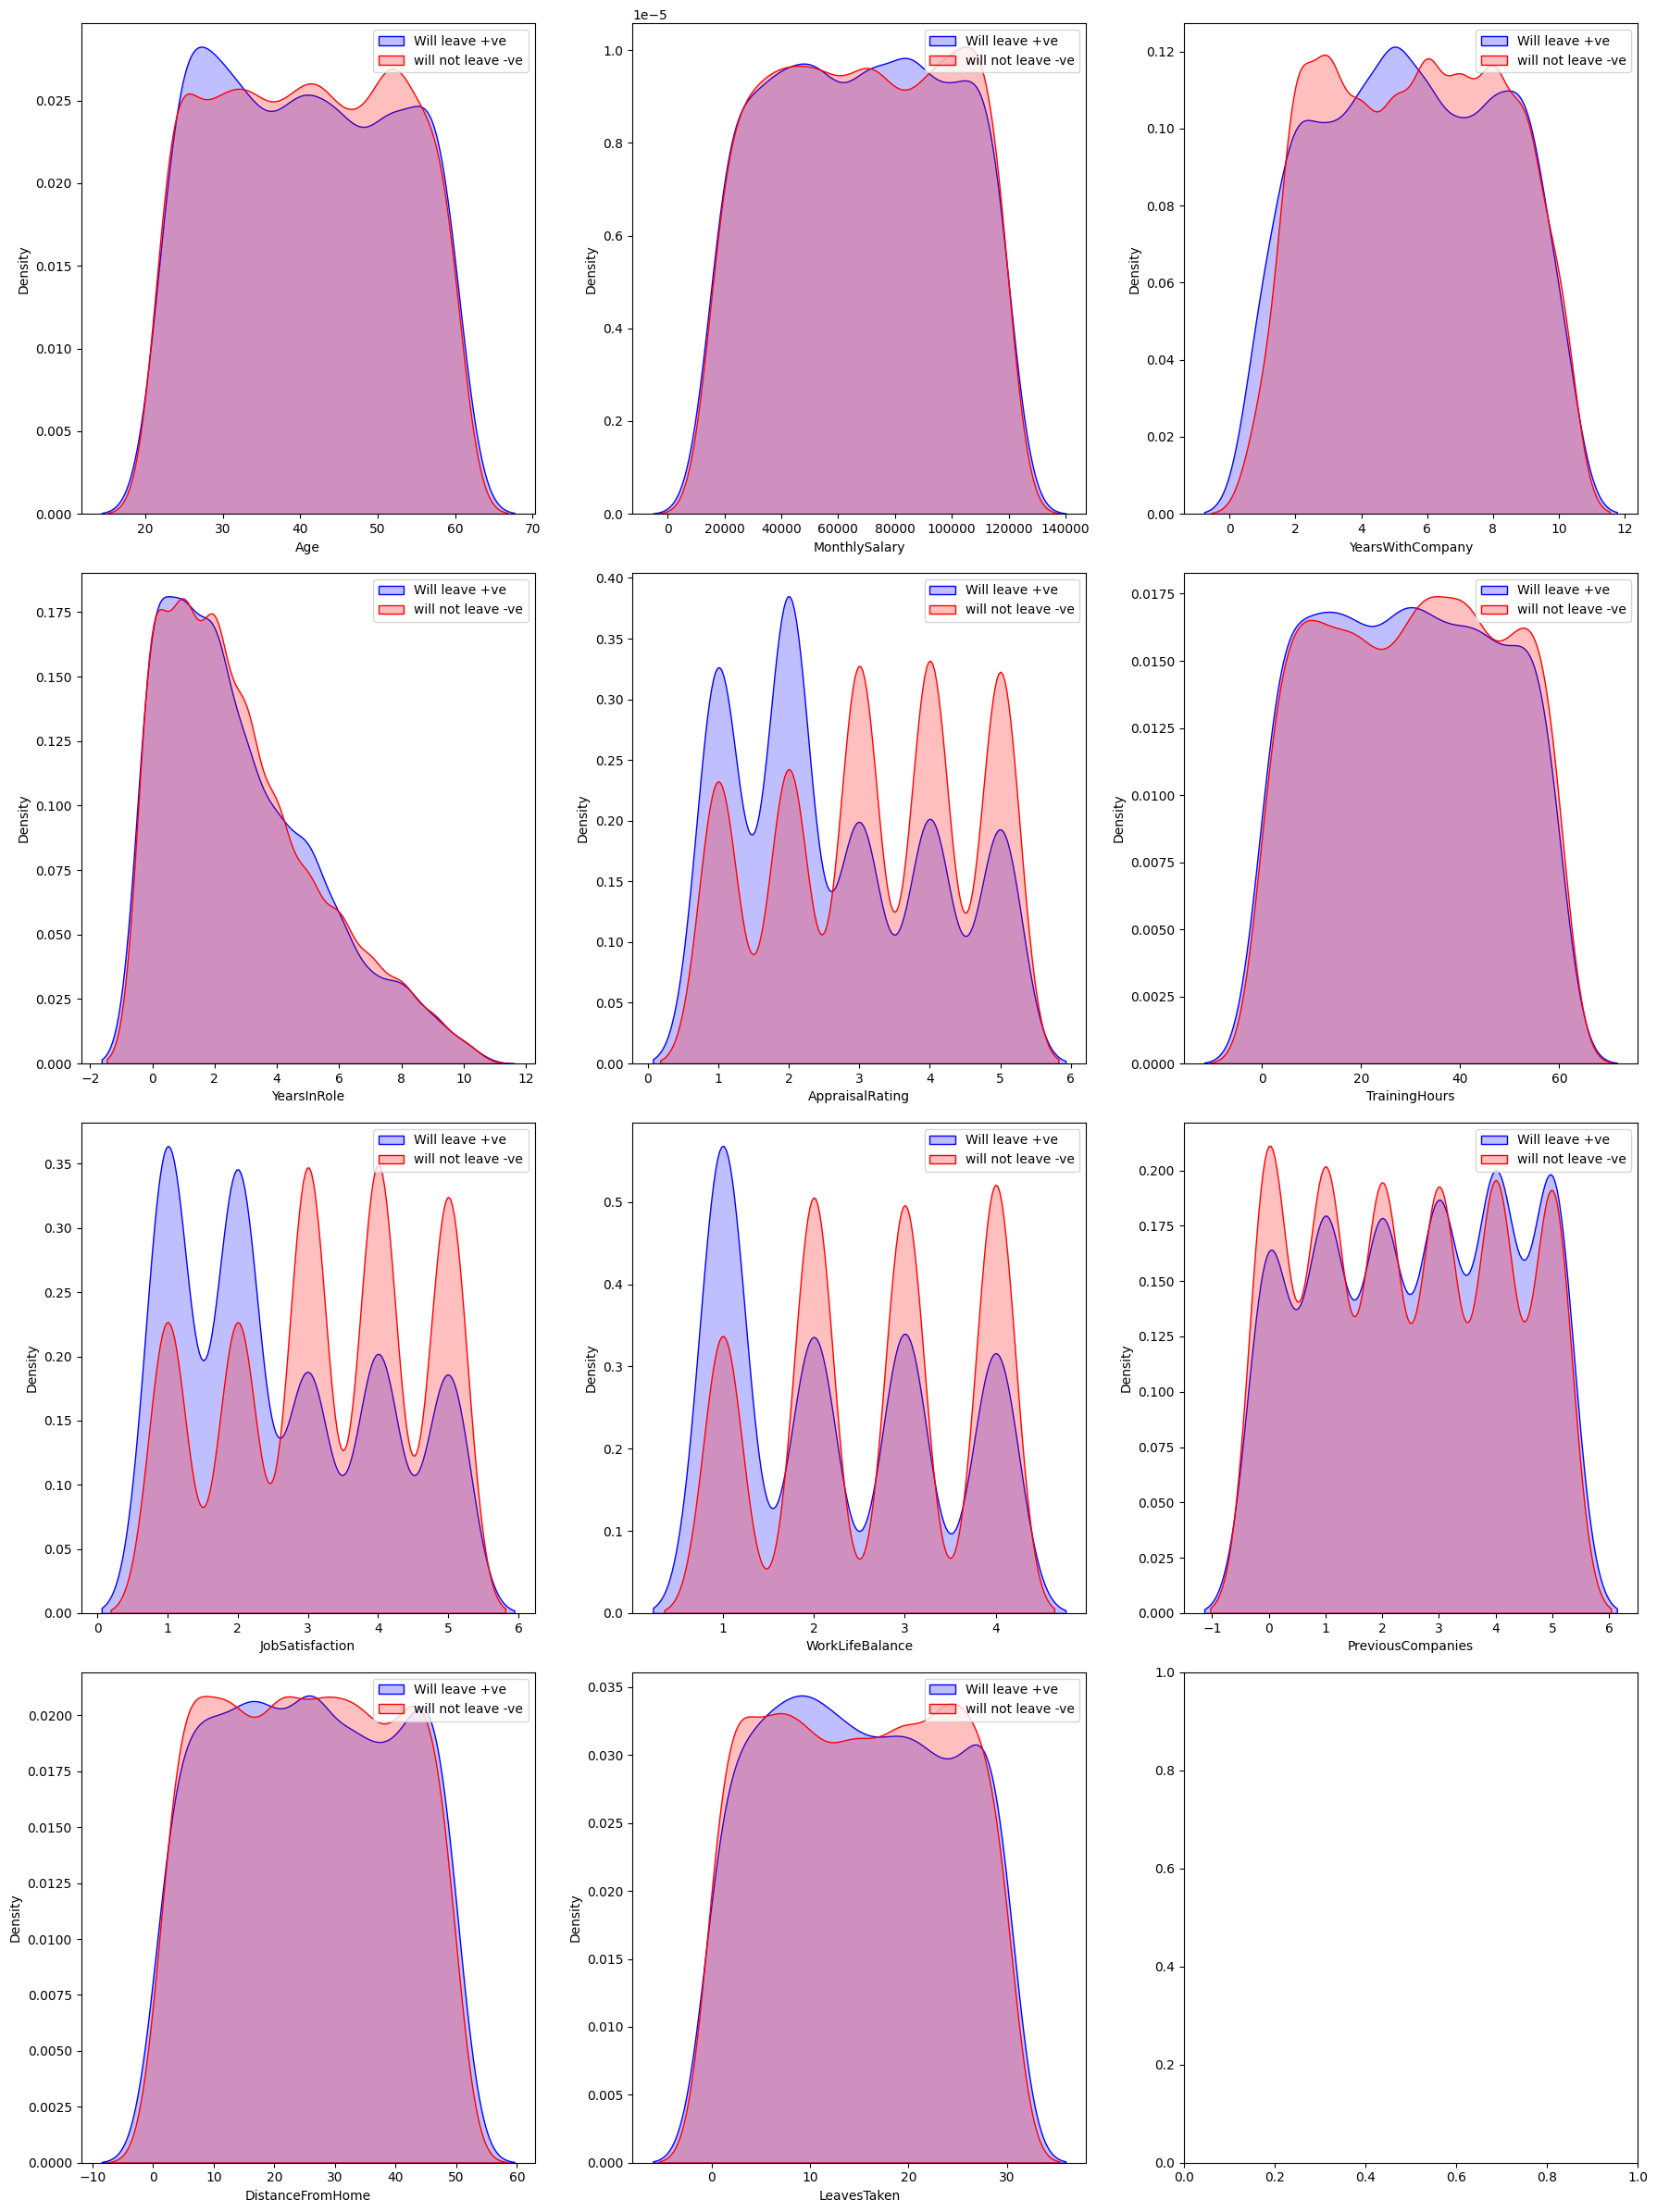

In [52]:

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if df[i].dtype!="category":
        
        sns.kdeplot(
            df[df["LeftCompany"]==1][i],
            color='blue', label='Will leave +ve',
            ax=axes[row,col],
            fill=True
            )
        
        sns.kdeplot(
            df[df["LeftCompany"]==0][i],
            color='red', 
            label='will not leave -ve',
            ax=axes[row,col],
            fill=True
            )
        
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()





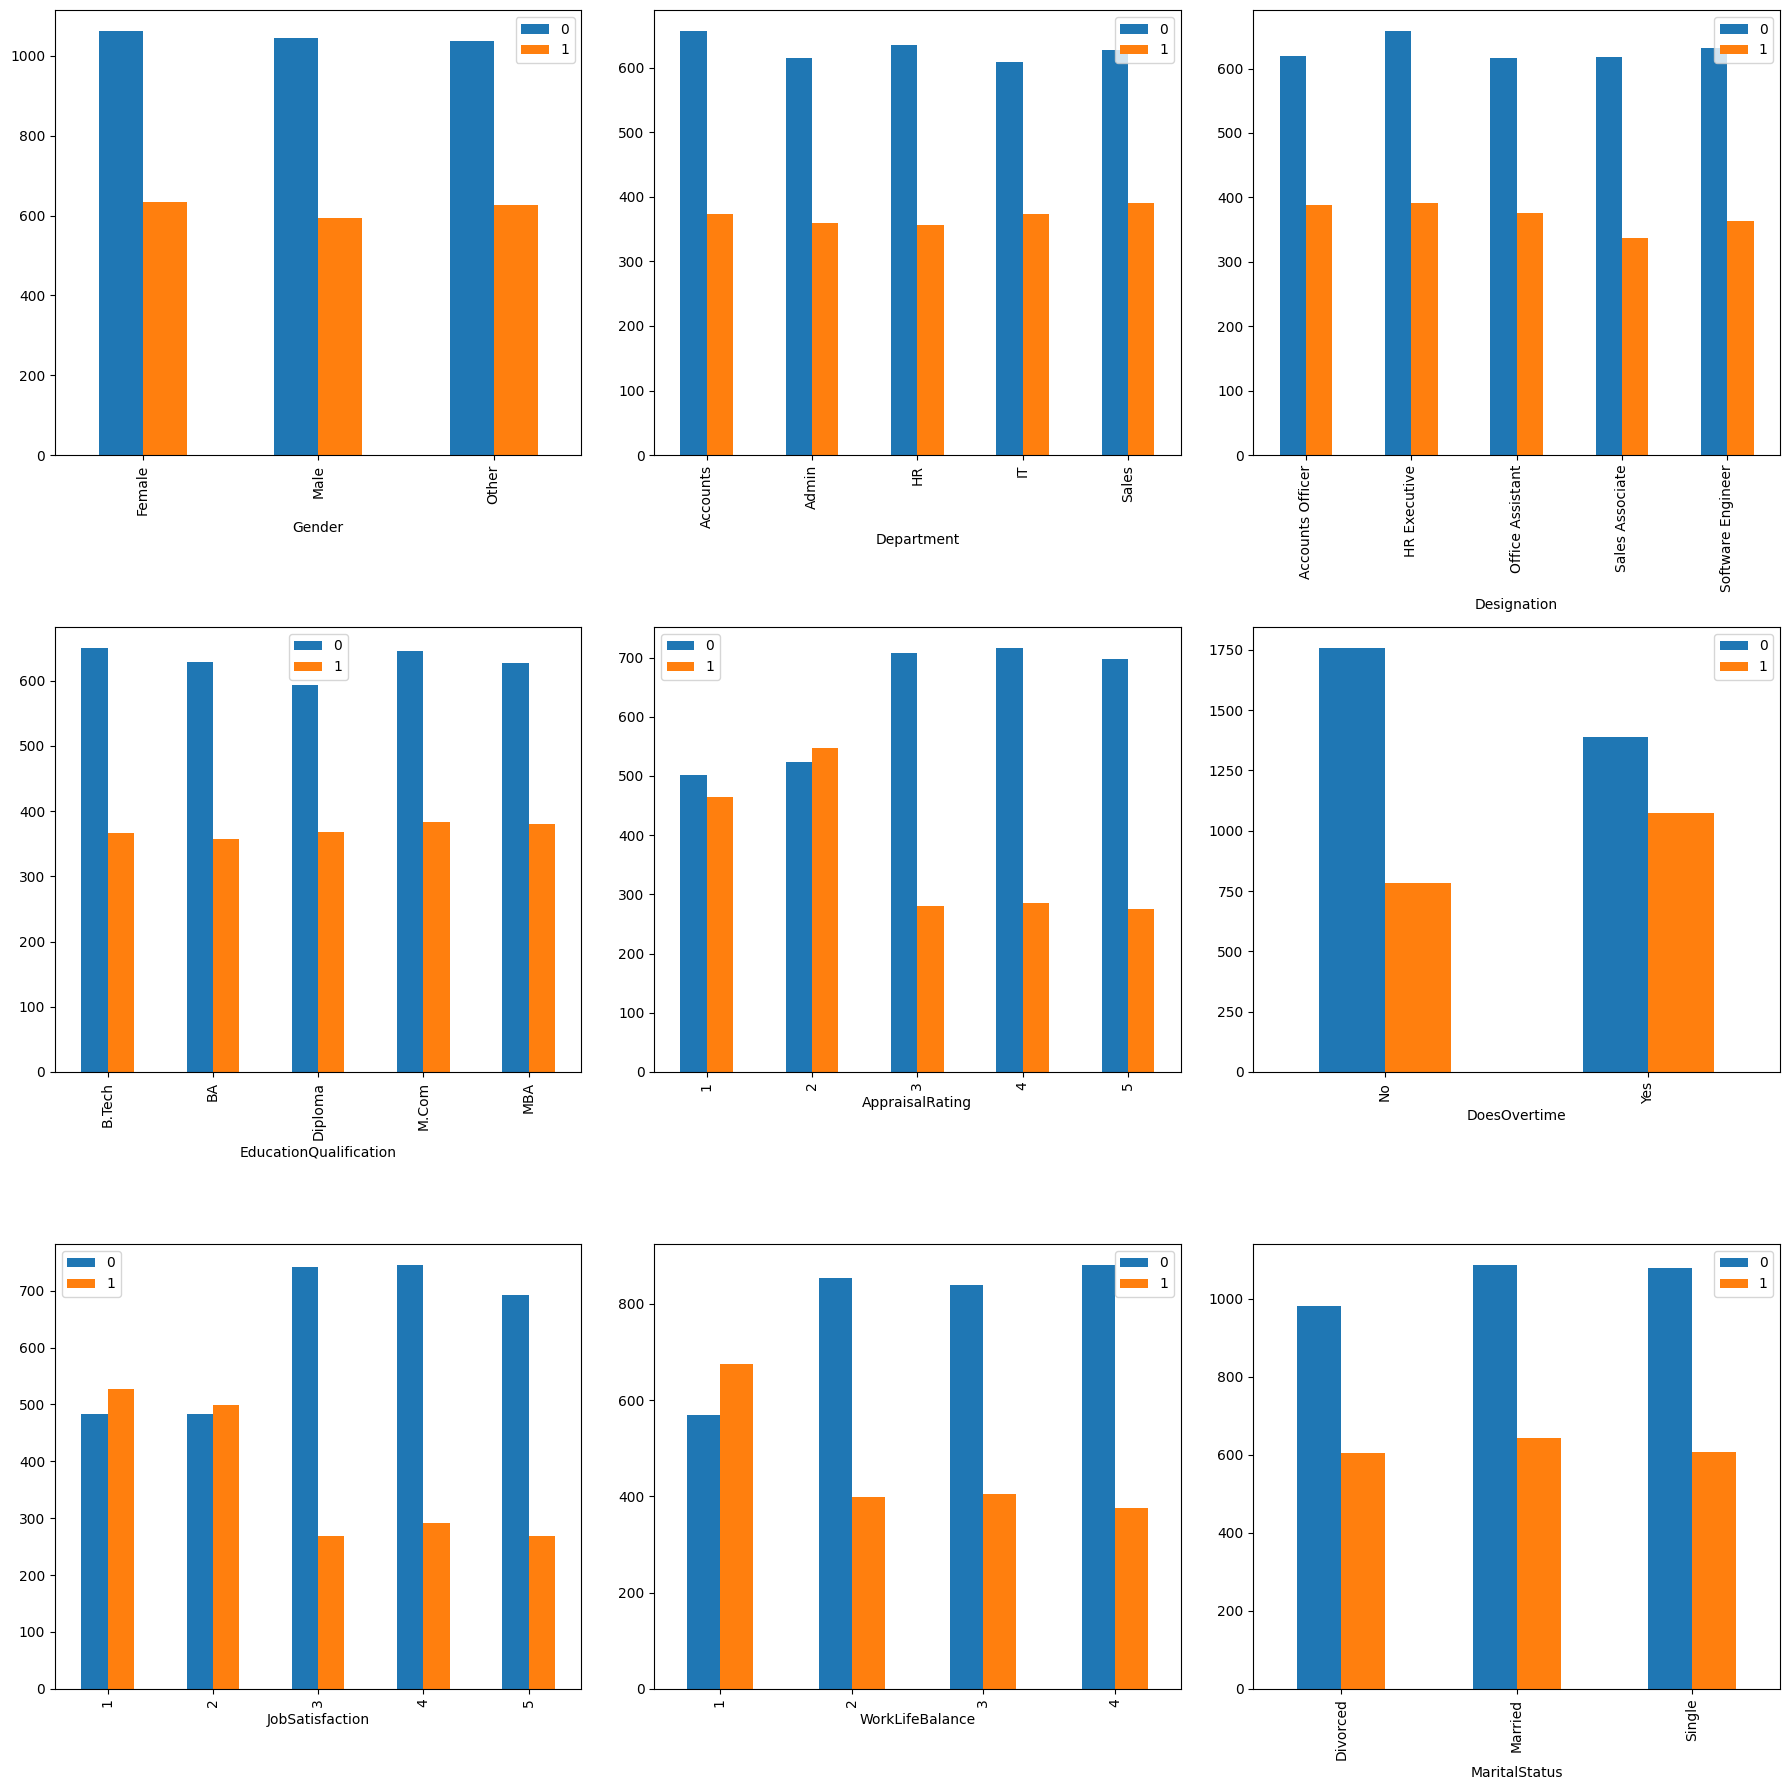

In [ ]:
count=0
collist=[]
for i in df.columns:
    if len(df[i].value_counts())<=7:
        count+=1
        collist.append(i)
total_plots = count-1 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if i != "LeftCompany" and len(df[i].value_counts())<=7:
        crosstb = pd.crosstab(df[i], df["LeftCompany"])
        crosstb.plot(kind="bar",ax=axes[row,col])
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols


plt.tight_layout(w_pad=2)
plt.show()